# Воспроизведение графиков из статьи "Simplifying Graph Convolutional Networks" (Figure 2)

В этом ноутбуке мы строим:
1. Коэффициенты фильтра $g(\lambda) = (1-\lambda)^K$ для $K \in \{1,2,4,6\}$.
2. Спектр одного столбца признаков в базисе собственных векторов нормализованного лапласиана.

Цель – наглядно подтвердить, что добавление самопетель и возведение матрицы распространения $S$ в степень $K$ создаёт низкочастотный фильтр.

In [8]:
# Импорты
import torch
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt
from torch_geometric.datasets import Planetoid

# Для воспроизводимости
np.random.seed(42)
torch.manual_seed(42)

## Загрузка датасета Cora
Используем готовый загрузчик из PyTorch Geometric.

In [9]:
dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]
edge_index = data.edge_index.numpy()  # [2, E]
n = data.num_nodes
x = data.x.numpy()  # матрица признаков [n, d]
print(f'Число узлов: {n}, число рёбер: {edge_index.shape[1]}, размер признаков: {x.shape[1]}')

Число узлов: 2708, число рёбер: 10556, размер признаков: 1433


## Построение нормализованной матрицы распространения $S$ и лапласиана $L_{\text{sym}}$

1. Создаём матрицу смежности с петлями: $\tilde{A} = A + I$.
2. Вычисляем нормализованную матрицу $S = \tilde{D}^{-1/2} \tilde{A} \tilde{D}^{-1/2}$.
3. Лапласиан: $L_{\text{sym}} = I - S$.

In [10]:
# Создаём разреженную матрицу смежности (неориентированный граф)
src, dst = edge_index[0], edge_index[1]
# Добавляем обратные рёбра, чтобы гарантировать симметрию
src_full = np.concatenate([src, dst])
dst_full = np.concatenate([dst, src])
data_ones = np.ones(len(src_full))
A = sp.coo_matrix((data_ones, (src_full, dst_full)), shape=(n, n))
# Убираем возможные дубликаты (приводим к бинарной)
A.data = np.ones_like(A.data)

# Добавляем самопетли
A_hat = A + sp.eye(n, dtype=np.float64)

# Степени и нормализация
deg_hat = np.array(A_hat.sum(axis=1)).flatten()
D_hat_inv_sqrt = sp.diags(1.0 / np.sqrt(deg_hat))
S = D_hat_inv_sqrt @ A_hat @ D_hat_inv_sqrt

# Симметричный нормированный лапласиан
L_sym = sp.eye(n, dtype=np.float64) - S
print('Матрица L_sym построена, тип:', type(L_sym))

Матрица L_sym построена, тип: <class 'scipy.sparse._csr.csr_matrix'>


## Вычисление собственных значений и векторов
Для ускорения используем `eigsh` из SciPy, который работает с разреженными матрицами.
Чтобы охватить весь диапазон $[0, 2]$, извлечём 250 наименьших (`'SA'`) и 250 наибольших (`'LA'`) собственных чисел.

In [11]:
k = 250
# Наименьшие собственные значения (низкие частоты)
vals_small, vecs_small = eigsh(L_sym, k=k, which='SA')
# Наибольшие собственные значения (высокие частоты)
vals_large, vecs_large = eigsh(L_sym, k=k, which='LA')

print(f'Диапазон наименьших λ: [{vals_small.min():.4f}, {vals_small.max():.4f}]')
print(f'Диапазон наибольших λ: [{vals_large.min():.4f}, {vals_large.max():.4f}]')

Диапазон наименьших λ: [-0.0000, 0.1710]
Диапазон наибольших λ: [1.4014, 1.6210]


## Фильтры $g(\lambda) = (1-\lambda)^K$
Объединяем все собственные значения и сортируем по возрастанию. Для каждого $K$ строим кривую фильтра.

In [12]:
# Объединяем и сортируем собственные значения
all_vals = np.concatenate([vals_small, vals_large])
all_vals.sort()
Ks = [1, 2, 4, 6]

# Выводим итоговый диапазон
print(f'Общий диапазон λ: [{all_vals.min():.4f}, {all_vals.max():.4f}]')
print(f'Всего собственных значений: {len(all_vals)}')

Общий диапазон λ: [-0.0000, 1.6210]
Всего собственных значений: 500


## Спектр одного признака
Берём третий столбец матрицы признаков $X$ (индекс 2), проецируем на собственные векторы и смотрим абсолютные величины проекций $|U^\top x|$.

In [13]:
feature_idx = 2  # третий признак, как в статье
x_vec = x[:, feature_idx].astype(np.float64)

# Проекции на низко- и высокочастотные векторы
proj_small = np.abs(vecs_small.T @ x_vec)
proj_large = np.abs(vecs_large.T @ x_vec)

print('Проекции вычислены.')

Проекции вычислены.


## Визуализация
Два подграфика:
- слева: кривые фильтров $g(\lambda)$ для разных $K$,
- справа: спектр выбранного признака.

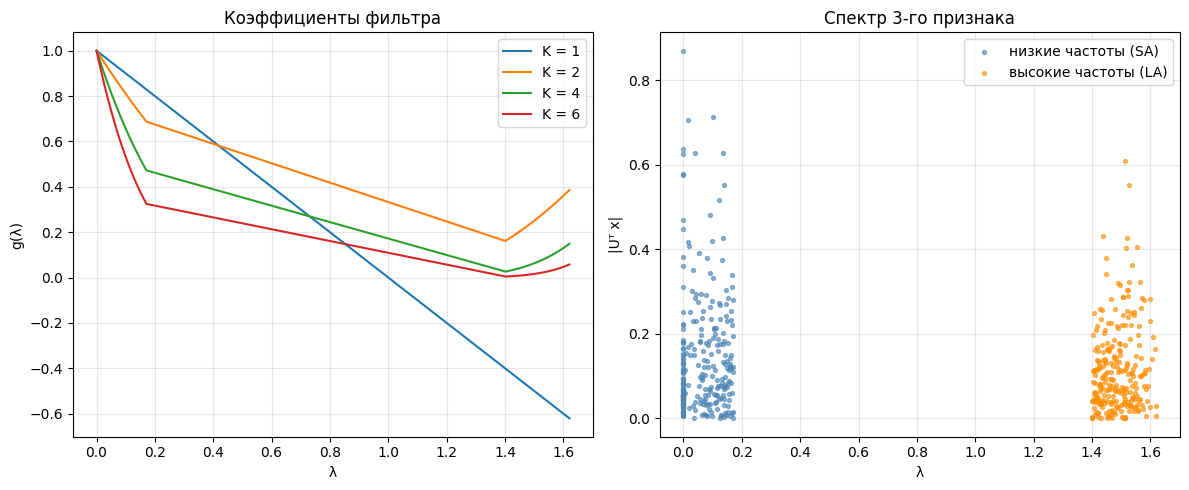

График сохранён в lowpass_filter.pdf


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Левый график: фильтры g(λ) ---
for K in Ks:
    g = (1 - all_vals)**K
    ax1.plot(all_vals, g, label=f'K = {K}')
ax1.set_xlabel('λ')
ax1.set_ylabel('g(λ)')
ax1.set_title('Коэффициенты фильтра')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Правый график: спектр признака ---
# Используем scatter для двух групп собственных векторов
ax2.scatter(vals_small, proj_small, alpha=0.6, s=8, color='steelblue', label='низкие частоты (SA)')
ax2.scatter(vals_large, proj_large, alpha=0.6, s=8, color='darkorange', label='высокие частоты (LA)')
ax2.set_xlabel('λ')
ax2.set_ylabel('|Uᵀ x|')
ax2.set_title(f'Спектр {feature_idx+1}-го признака')
ax2.legend()
ax2.grid(True, alpha=0.3)
# При необходимости можно включить логарифмический масштаб:
# ax2.set_yscale('log')

plt.tight_layout()
plt.savefig('lowpass_filter.pdf', bbox_inches='tight')
plt.show()
print('График сохранён в lowpass_filter.pdf')

## Вывод
Мы воспроизвели ключевую иллюстрацию из статьи SGC. Видно, что с ростом $K$ фильтр $(1-\lambda)^K$ всё сильнее подавляет высокие частоты ($\lambda$ близкие к 2), выступая в роли низкочастотного фильтра. Спектр признака демонстрирует, какие частоты доминируют в данных.